In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors

In [2]:
msk_path = "data/mskcc_cellpaper_zygosity.tsv.gz"
roles_path = "data/generoles.tsv"
wgd_path = "data/data_clinical_sample.txt"

In [3]:
msk = pd.read_csv(msk_path, sep='\t')
roles = pd.read_csv(roles_path, sep='\t')
wgd = pd.read_csv(wgd_path, sep='\t', header=4)

/home/sabari/niveditam/miniconda3/envs/equinox_minimal/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3508: DtypeWarning: Columns (13) have mixed types.Specify dtype option on import or set low_memory=False.
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
def config_rcparams():
    plt.rcParams['font.family'] = ['sans-serif']
    plt.rcParams['font.sans-serif'] = ['arial']
    plt.rcParams['svg.fonttype'] = 'none' 
    plt.rcParams['mathtext.fontset'] = 'custom'
    plt.rcParams['mathtext.cal'] = 'arial'
    plt.rcParams['mathtext.rm'] = 'arial'
    plt.rcParams['axes.linewidth'] = 0.7
    plt.rcParams['xtick.major.width'] = 0.7
    plt.rcParams['ytick.major.width'] = 0.7
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['ytick.major.size'] = 3

---

# Fig S9B

In [5]:
# preparing dataset

msk_mod = msk[(msk.CANCER_TYPE=='all')&(msk.mutation_class=='driver')]
msk_mod_net = msk_mod[(msk_mod.PRIM_MET!='Unknown')&(msk_mod.zyg_class!='loh')]

wgd_mod = wgd[~wgd['SAMPLE_TYPE'].isin(['Unknown','Local Recurrence'])].copy()
roles_mod = roles[['Hugo_Symbol','role']].copy()

tmp1 = msk_mod_net[['SAMPLE_ID','PRIM_MET','purity','fga','Hugo_Symbol','zyg_class']].copy()
tmp2 = wgd_mod[['SAMPLE_ID','SAMPLE_TYPE','FACETS_WGD','FACETS_PLOIDY','FACETS_PURITY']].copy()

msk_wgd = pd.merge(tmp1,tmp2, on=['SAMPLE_ID'])
print(len(tmp1))
print(len(tmp2))
print(len(msk_wgd))

50608
53708
50314


In [6]:
# continued...

freq = msk_wgd.groupby(['SAMPLE_TYPE','Hugo_Symbol','zyg_class'])['SAMPLE_ID'].nunique().to_frame().reset_index().pivot(index=['SAMPLE_TYPE','Hugo_Symbol'], columns='zyg_class',values='SAMPLE_ID').fillna(0).reset_index()
freq['tot'] = freq['biallelic']+freq['het']
freq['twohitfreq'] = freq['biallelic']/freq['tot']
freq = freq[freq['tot']>=5]
print(len(freq))
freq = pd.merge(freq,roles_mod, on='Hugo_Symbol', how='left')
print(len(freq))

freq_piv = freq.pivot(index=['Hugo_Symbol','role'],columns='SAMPLE_TYPE',values='twohitfreq').reset_index()
tmp = freq.groupby(['Hugo_Symbol'])['tot'].sum().to_frame().reset_index()
freq_piv = pd.merge(freq_piv, tmp, on='Hugo_Symbol', how='left')

tmp = freq[freq.SAMPLE_TYPE=='Metastasis'][['Hugo_Symbol','tot']].rename(columns={'tot':'mettot'})
freq_piv = pd.merge(freq_piv, tmp, on='Hugo_Symbol', how='left')
freq_piv['metbytot'] = freq_piv['mettot']/freq_piv['tot']

466
466


83
SignificanceResult(statistic=0.914532250453469, pvalue=1.398527232190008e-33)


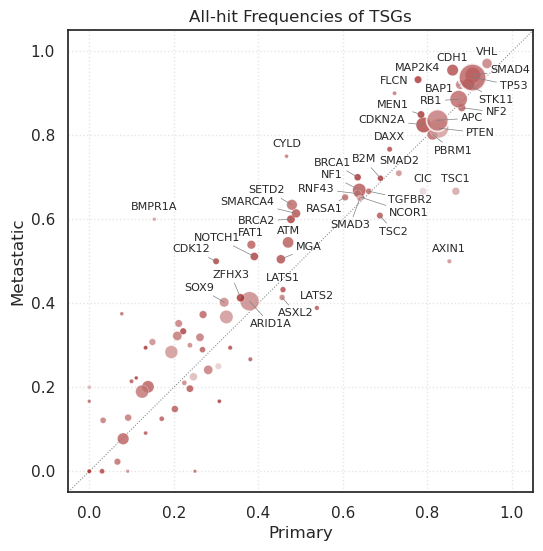

In [7]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

genes_to_annotate = {
    'PBRM1':(15,-20),
    'CDKN2A':(-30,-5),
    'MEN1':(-20,-2),
    'PTEN':(30,-12),
    'APC':(25,-7),
    'STK11':(20,-20),
    'SMAD4':(27,-5),
    'TP53':(30,-15),
    'BAP1':(-15,-12),
    'NF2':(25,-12),
    'RB1':(-20,-10),
    'SMARCA4':(-35,0),
    'BRCA2':(-25,-10),
    'NOTCH1':(-27,5),
    'CDK12':(-18,0),
    'MGA':(20,0),
    'ASXL2':(10,-20),
    'SOX9':(-18,2),
    'ARID1A':(15,-25),
    'ZFHX3':(-7,8),
    'SETD2':(-18,2),
    'B2M':(-12,5),
    'BRCA1':(-18,2),
    'TGFBR2':(30,-15),
    'TSC2':(10,-20),
    'RASA1':(-15,-17),
    'NF1':(-20,2),
    'RNF43':(-30,-5),
    'NCOR1':(35,-20),
    'SMAD3':(-7,-28),
    
}

data = freq_piv[freq_piv.role=='TSG'].dropna()
print(len(data))

size_lower = 5
size_upper = 1300
hue_lower = 0.1
hue_upper = np.percentile(data['metbytot'], 95)  

data1 = data[data.tot<=1300]
data2 = data[(data.tot>1300)&(data.tot<2000)]
data3 = data[(data.tot>3000)]

palette = sns.color_palette("light:brown", as_cmap=True)
ax = sns.scatterplot(data=data1,x='Primary', y='Metastasis', size='tot', alpha=0.8, hue='metbytot', palette=palette, legend=False,  sizes=(5, 200),     
                     size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)
ax = sns.scatterplot(data=data2,x='Primary', y='Metastasis', legend=False, alpha=0.8,  s=250, hue='metbytot', palette=palette, hue_norm=(data['metbytot'].min(), hue_upper), zorder=1)     
ax = sns.scatterplot(data=data3,x='Primary', y='Metastasis', legend=False, alpha=0.8,  s=400, hue='metbytot', palette=palette, hue_norm=(data['metbytot'].min(), hue_upper), zorder=1)     

labelled = data[(data['Metastasis']>=0.4)|(data['Primary']>=0.4)]
for _, row in labelled.iterrows():
    x, y = row['Primary'], row['Metastasis']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )


ax.set_xlabel('Primary',fontsize=12)
ax.set_ylabel('Metastatic',fontsize=12)
ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')
plt.title('All-hit Frequencies of TSGs')

tmp = data[['Metastasis','Primary']].dropna()
print(stats.spearmanr(tmp['Metastasis'].values,tmp['Primary'].values))

plt.show()

---

# Fig S9A

In [8]:
# preparing dataset

msk_wgd['WGD'] = msk_wgd['FACETS_WGD'].replace({True:'WGD+',False:'WGD-'})

freq = msk_wgd.groupby(['WGD','Hugo_Symbol','zyg_class'])['SAMPLE_ID'].nunique().to_frame().reset_index().pivot(index=['WGD','Hugo_Symbol'], columns='zyg_class',values='SAMPLE_ID').fillna(0).reset_index()
freq['tot'] = freq['biallelic']+freq['het']
freq['twohitfreq'] = freq['biallelic']/freq['tot']
freq = freq[freq['tot']>=5]
print(len(freq))
freq = pd.merge(freq,roles_mod, on='Hugo_Symbol', how='left')
print(len(freq))

freq_piv = freq.pivot(index=['Hugo_Symbol','role'],columns='WGD',values='twohitfreq').reset_index()
tmp = freq.groupby(['Hugo_Symbol'])['tot'].sum().to_frame().reset_index()
freq_piv = pd.merge(freq_piv, tmp, on='Hugo_Symbol', how='left')

tmp = freq[freq.WGD=='WGD+'][['Hugo_Symbol','tot']].rename(columns={'tot':'wgdtot'})
freq_piv = pd.merge(freq_piv, tmp, on='Hugo_Symbol', how='left')
freq_piv['wgdbytot'] = freq_piv['wgdtot']/freq_piv['tot']

453
453


83
SignificanceResult(statistic=0.8735544158226678, pvalue=4.7156485955425996e-27)


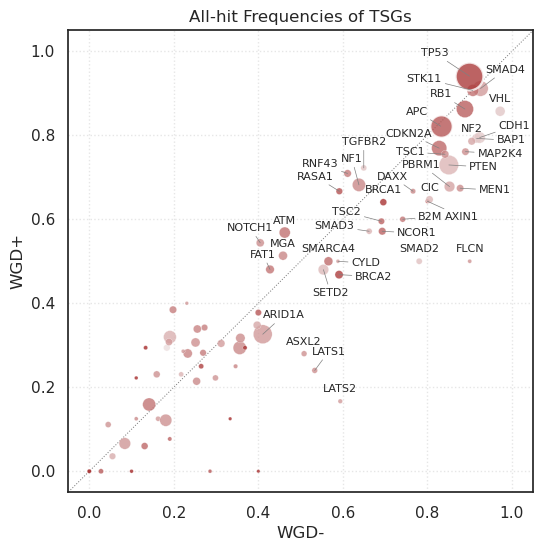

In [9]:
config_rcparams()

sns.set(rc={'figure.figsize':(6,6)})
sns.set_style('white')

genes_to_annotate = {
    'LATS1':(10,5),
    'ARID1A':(15,5),
    'FAT1':(-5,2),
    'NOTCH1':(-7,2),
    'BRCA2':(25,-10),
    'SETD2':(5,-25),
    'CYLD':(20,-10),
    'RNF43':(-20,-2),
    'RASA1':(-17,2),
    'TGFBR2':(0,10),
    'NF1':(-5,10),
    'SMAD3':(-25,-5),
    'TP53':(-25,8),
    'STK11':(-35,0),
    'RB1':(-17,2),
    'APC':(-17,2),
    'SMAD4':(18,5),
    'B2M':(20,-7),
    'NCOR1':(25,-10),
    'AXIN1':(25,-20),
    'TSC2':(-25,-2),
    'DAXX':(-15,2),
    'PBRM1':(-20,7),
    'MEN1':(25,-10),
    'MAP2K4':(25,-10),
    'PTEN':(25,-10),
    'CDKN2A':(-22,2),
    'TSC1':(-25,-7),
    'BAP1':(25,-10),
    'CDH1':(25,0),
}

data = freq_piv[freq_piv.role=='TSG'].dropna()
print(len(data))

size_lower = 5
size_upper = 1300 #np.percentile(data['tot'], 95)   
hue_lower = 0.1
hue_upper = np.percentile(data['wgdbytot'], 95)  

data1 = data[data.tot<=1300]
data2 = data[(data.tot>1300)&(data.tot<2000)]
data3 = data[(data.tot>3000)]

palette = sns.color_palette("light:brown", as_cmap=True)
ax = sns.scatterplot(data=data1,x='WGD-', y='WGD+', size='tot', alpha=0.8, hue='wgdbytot', palette=palette, legend=False,  sizes=(5, 200),     
                     size_norm=(size_lower, size_upper), hue_norm=(hue_lower, hue_upper), zorder=1)
ax = sns.scatterplot(data=data2,x='WGD-', y='WGD+', legend=False, alpha=0.8,  s=250, hue='wgdbytot', palette=palette, hue_norm=(data['wgdbytot'].min(), hue_upper), zorder=1)     
ax = sns.scatterplot(data=data3,x='WGD-', y='WGD+', legend=False, alpha=0.8,  s=400, hue='wgdbytot', palette=palette, hue_norm=(data['wgdbytot'].min(), hue_upper), zorder=1)     


labelled = data[(data['WGD+']>=0.41)|(data['WGD-']>=0.41)]
for _, row in labelled.iterrows():
    x, y = row['WGD-'], row['WGD+']
    label = row['Hugo_Symbol']
    dx, dy = (0, 5)  
    
    if label in genes_to_annotate:
        extra_dx, extra_dy = genes_to_annotate[label]
        dx += extra_dx
        dy += extra_dy
    
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            ha="center", va="bottom",  
            fontsize=8,
            arrowprops=dict(
                arrowstyle="-",                
                color="gray",
                lw=0.5,
                shrinkA=500, shrinkB=200
            )
        )
                
    else:
        ax.annotate(
            label,
            xy=(x, y),                         
            xytext=(dx,dy),                     
            textcoords="offset points",
            fontsize=8,
            ha="center", va="bottom",          
        )

ax.set_ylim(-0.05,1.05)
ax.set_xlim(-0.05,1.05)
ax.plot([-0.1, 1.1], [-0.1, 1.1],color='grey',linestyle=':',linewidth=0.75, zorder=0)
ax.grid(True,color='#E6E6E6', linestyle =':')
plt.title('All-hit Frequencies of TSGs')

tmp = data[['WGD+','WGD-']].dropna()
print(stats.spearmanr(tmp['WGD+'].values,tmp['WGD-'].values))

plt.show()

---